# PROYECTO FINAL: Tu Propio Clasificador de Imagenes

**Universidad Don Bosco - Diplomado Python Avanzado**

**Modulo 4 - Sesion 4**

---

## El Reto

Construye un clasificador de imagenes con TU PROPIO TEMA y deployalo como aplicacion web publica.

## Tiempo disponible

Tienes **1 semana** para entregar. Asumiendo 2 horas por noche, son aproximadamente **12-14 horas de trabajo**. Por eso el proyecto esta diseñado para ser realizable en ese tiempo, sin esquinas escondidas que te quemen 5 horas extra.

## Lo que vas a hacer

1. Elegir un tema personal (no academico)
2. Recolectar tu dataset (~30 imagenes por clase, minimo 3 clases)
3. Entrenar UN modelo con Transfer Learning (lo que vimos en clase)
4. Analizar resultados (confusion matrix, errores)
5. Crear app web con Streamlit
6. Deployar en Streamlit Cloud (gratis, ~3 minutos)
7. Documentar en README

Al terminar tendras un proyecto **mostrable en tu portafolio** con URL publica.

---


## Reglas del Proyecto

### NO PERMITIDO

- NO datasets clasicos: CIFAR-10, MNIST, Fashion-MNIST, ImageNet
- NO Cats vs Dogs (esta en todos los tutoriales)
- NO Personajes de Simpsons (ya lo hicimos en clase)
- NO copiar el tema de un companero

### SI PERMITIDO Y RECOMENDADO

- Algo personal y unico
- Algo local (cultura, comida, naturaleza salvadorena)
- Algo divertido que te emocione mostrar

---

## Ideas de Proyectos

### Cultura y Comida Local (muy recomendado)

- **Pupusas**: queso, chicharron, frijol, revueltas
- **Frutas tropicales**: zapote, anona, mamey, jocote, maranon
- **Bebidas locales**: horchata, ensalada, atol, kolashanpan

### Entretenimiento

- **Personajes** de tu serie favorita (que NO sea Simpsons)
- **Pokemon** por tipo (agua, fuego, planta)
- **Marvel/DC**: 5 superheroes
- **Anime**: Dragon Ball, Naruto, etc

### Productos y Marcas

- **Marcas de tenis**: Nike, Adidas, Puma, etc
- **Logos** de redes sociales o cervezas
- **Modelos** de carros (sedan, SUV, pickup)

### Tip para elegir bien

**Elige algo donde puedas conseguir las imagenes facil**. Si tu tema requiere fotos especificas que solo se ven 2 veces al ano, vas a sufrir mucho.

---


## Requisitos Tecnicos

### Dataset

| Aspecto | Minimo | Recomendado |
|---------|--------|-------------|
| Clases | 3 | 4-5 |
| Imagenes por clase | 30 | 50+ |
| Diversidad | Variada | Muy variada |

### Modelo

**UN modelo con Transfer Learning** (similar al de clase). NO necesitas hacer la CNN desde cero — esa ya la hicimos juntos. Aqui te enfocas en lo que mejor funciona.

### Deploy

App web publica en **Streamlit Cloud** (gratis, conectada a GitHub).

---

## Entregables

1. **Este notebook completado** con tu codigo y reflexiones
2. **Modelo entrenado** (`.keras`)
3. **App publica en Streamlit Cloud** (URL accesible para cualquiera)
4. **README.md** con descripcion, resultados y reflexiones

> **Nota**: No hay video demo. La URL de Streamlit es tu demo.

---

## Evaluacion (100 puntos)

| Criterio | Puntos | Que se evalua |
|----------|--------|---------------|
| Funcionamiento tecnico | 35 | El modelo entrena y predice correctamente |
| Calidad del dataset | 15 | Cantidad, balance, calidad de imagenes |
| Analisis de errores | 15 | Confusion matrix + interpretacion reflexiva |
| Deploy funcionando | 20 | URL publica accesible y funcional |
| Documentacion | 10 | README completo y claro |
| Originalidad | 5 | Tema unico e interesante |

### Bonus (hasta +10)

- **+5**: UI especialmente cuidada en Streamlit (tu app se ve profesional)
- **+5**: Mas de 5 clases con buen accuracy (>80%)

---

## IMPORTANTE: Este Notebook es Una Guia

Cada paso tiene:
- **Que hacer** y **por que**
- **Pistas** sin dar la solucion
- **TODOs** para que tu escribas el codigo

**No copies codigo** del notebook de Simpsons sin entenderlo. Tu proyecto es diferente.

---


## Paso 1: Planificar el Proyecto (15 min)

Antes de tocar codigo, define con claridad:

**1. Que tema elegiste?**

No solo "elegi Pokemon porque me gusta". Profundiza:
- Que tan facil sera conseguir imagenes?
- Que clases especificas vas a usar?

**2. Cuales son tus clases EXACTAS?**

- Mal: "Tipos de comida" (muy amplio, vago)
- Bien: "Pupusas: queso, chicharron, frijol, revueltas"

**3. De donde sacaras las imagenes?**

- Google Images (busqueda manual)
- Fotos propias
- Datasets de Kaggle de temas raros

### TODO 1: Configura las variables de tu proyecto


In [1]:
# TODO: Define tu proyecto
!pip install tensorflow
# Verificar TensorFlow y GPU
import tensorflow as tf

print(f'TensorFlow version: {tf.__version__}')
gpus = tf.config.list_physical_devices('GPU')
print(f'GPU disponible: {len(gpus)}')

if not gpus:
    print('\nADVERTENCIA: No hay GPU activa.')
    print('El notebook funciona, pero el entrenamiento sera mucho mas lento.')
    print('En Colab: Runtime > Change runtime type > T4 GPU')
else:
    print('GPU lista para entrenar.')

PROYECTO_NOMBRE = 'Clasificador de lugares turisticos'  # Ejemplo: 'Clasificador de Pupusas'
PROYECTO_DESCRIPCION = 'Modelo para identificar mis lugares turisticos favoritos'
CLASES = ['Playa','Ciudad','Montania']  # Ejemplo: ['queso', 'chicharron', 'frijol', 'revueltas']

# Validacion automatica
assert PROYECTO_NOMBRE, 'Clasificador de lugares turisticos'
assert PROYECTO_DESCRIPCION, 'Modelo para identificar mis lugares turisticos favoritos'
assert len(CLASES) >= 3, 'Necesitas al menos 3 clases'

print(f'Proyecto: {PROYECTO_NOMBRE}')
print(f'Clases ({len(CLASES)}): {CLASES}')

# Imports principales
import os
import json
import random
import shutil
from pathlib import Path
from google.colab import drive

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import classification_report, confusion_matrix

# Configuracion visual y reproducibilidad
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.25

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Extensiones de imagen validas (lo usaremos aqui y en celdas posteriores)
image_extensions = {'.jpg', '.jpeg', '.png'}

# Montar Google Drive
drive.flush_and_unmount()  # Clear cache
drive.mount('/content/drive', force_remount=True)

# Verifica que se montó correctamente
!ls /content/drive/MyDrive/

Mounted at /content/drive
 Agile_Scrum			     'Houston Dec 2022.gsheet'
'Appointment Letter (1).gdoc'	     'INFORMACIÓN SOLICITADA.pdf'
'Appointment Letter.docx'	      Itinerary.gsheet
'Appointment Letter.gdoc'	      JavierWilitoRich
'Calculo pago.gsheet'		      Juegos
'Colab Notebooks'		     'oferta de beca 07-05-10.gdoc'
'Conf Guzman Alfaro.pdf'	      OTORRINOLARINGOLOGIA.xlsx
'Cover Letter ENG.gdoc'		     'PANTALLA DMR302.txt'
'Cover Letter ENG.pdf'		     'Parejas Papers.gdoc'
'Curriculum-RGA ESP.pdf'	     'PREGUNTAS CHUNCHES VIEJOS.docx'
'Decameron Agosto 2025 (1).gdoc'      Projects
'Decameron Agosto 2025.gdoc'	      RGA_NV.gdoc
 DMR302.txt			      RGA.pdf
'Documentos personales'		     'Ricardo Guzman'
 DryTownWaterPark.pdf		     'Ricardo Guzman (1)'
'Emision VISAS.JPG'		      Roofs_For_Rich_Green_People.gdoc
'Estructura de contenido.docx'	     'Second mortgage.xlsx'
'Firmar JApplets.gdoc'		      tasacrecimientopibtrimestralusa.gsheet
'FSV october 1st pay.pdf'	      turismo
'Goog

## Paso 2: Recolectar el Dataset (3-4 horas)

Esta parte la haces **fuera del notebook**. Es trabajo manual pero es lo mas importante.

### Estrategia recomendada: Google Images manual

Es lento pero da el mejor control de calidad.

**Paso a paso**:

1. Busqueda especifica: "pupusa de queso plato" en lugar de solo "pupusa"
2. Filtra por tamano: Tools > Size > Medium o Large
3. Click derecho > Save image as > guarda en la carpeta de la clase
4. Renombra archivos con numero (img_001.jpg, img_002.jpg, etc)

**Calidad sobre cantidad**: 30 imagenes excelentes son mejor que 50 mediocres.

### Estructura en Google Drive

```text
mi_proyecto/
  raw_data/
    clase_1/
      img_001.jpg
      img_002.jpg
    clase_2/
      ...
    clase_3/
      ...
```

### Plan B: Si no logras recolectar suficientes

Busca en Kaggle un dataset de tu tema. **Filtra solo las clases que tu eliges**, no uses todo. Puedes adaptar el codigo de descarga del notebook de Simpsons.

### TODO 2: Monta Drive y configura rutas


In [2]:
# TODO: Monta Google Drive
# Pista: from google.colab import drive

# Tu codigo aqui


# TODO: Configura rutas
ROOT = '/content/drive/MyDrive/turismo'  # Ej: '/content/drive/MyDrive/mi_proyecto'
RAW_DATA_DIR = '/content/drive/MyDrive/turismo/raw_data'  # Ej: '/content/drive/MyDrive/mi_proyecto/raw_data'
WORK_DIR = '/content/drive/MyDrive/turismo/work'  # Ej: '/content/drive/MyDrive/mi_proyecto/work'

import os
assert RAW_DATA_DIR, 'Configura RAW_DATA_DIR'
assert os.path.exists(RAW_DATA_DIR), f'No existe: {RAW_DATA_DIR}'
print(f'Datos en: {RAW_DATA_DIR}')


Datos en: /content/drive/MyDrive/turismo/raw_data


## Paso 3: Explorar el Dataset (30 min)

**Nunca entrenes a ciegas**. Explora primero.

### TODO 3: Cuenta imagenes por clase

**Pistas**:
- Recorre cada clase en CLASES
- Usa `os.listdir(carpeta_de_clase)`
- Filtra solo .jpg, .jpeg, .png


In [3]:
# TODO: Cuenta cuantas imagenes hay por clase
# Output esperado:
#   clase_1: 35 imagenes
#   clase_2: 42 imagenes
#   ...

# Tu codigo aqui

LUGARES = sorted([p for p in Path(RAW_DATA_DIR).iterdir() if p.is_dir()])
conteo = {}

for lugar in LUGARES:
    archivos = [f for f in lugar.iterdir() if f.suffix.lower() in image_extensions]
    conteo[lugar.name] = len(archivos)

print(conteo)



{'Ciudad': 80, 'Montania': 80, 'Playa': 80}


**Reflexiona**:
- Esta balanceado tu dataset?
- Tienes minimo 30 por clase?

### TODO 4: Visualiza ejemplos

Mostrar 3 imagenes de cada clase en un grid. Si descubres problemas (marcas de agua, imagenes equivocadas, duplicados), arreglalos AHORA antes de seguir.


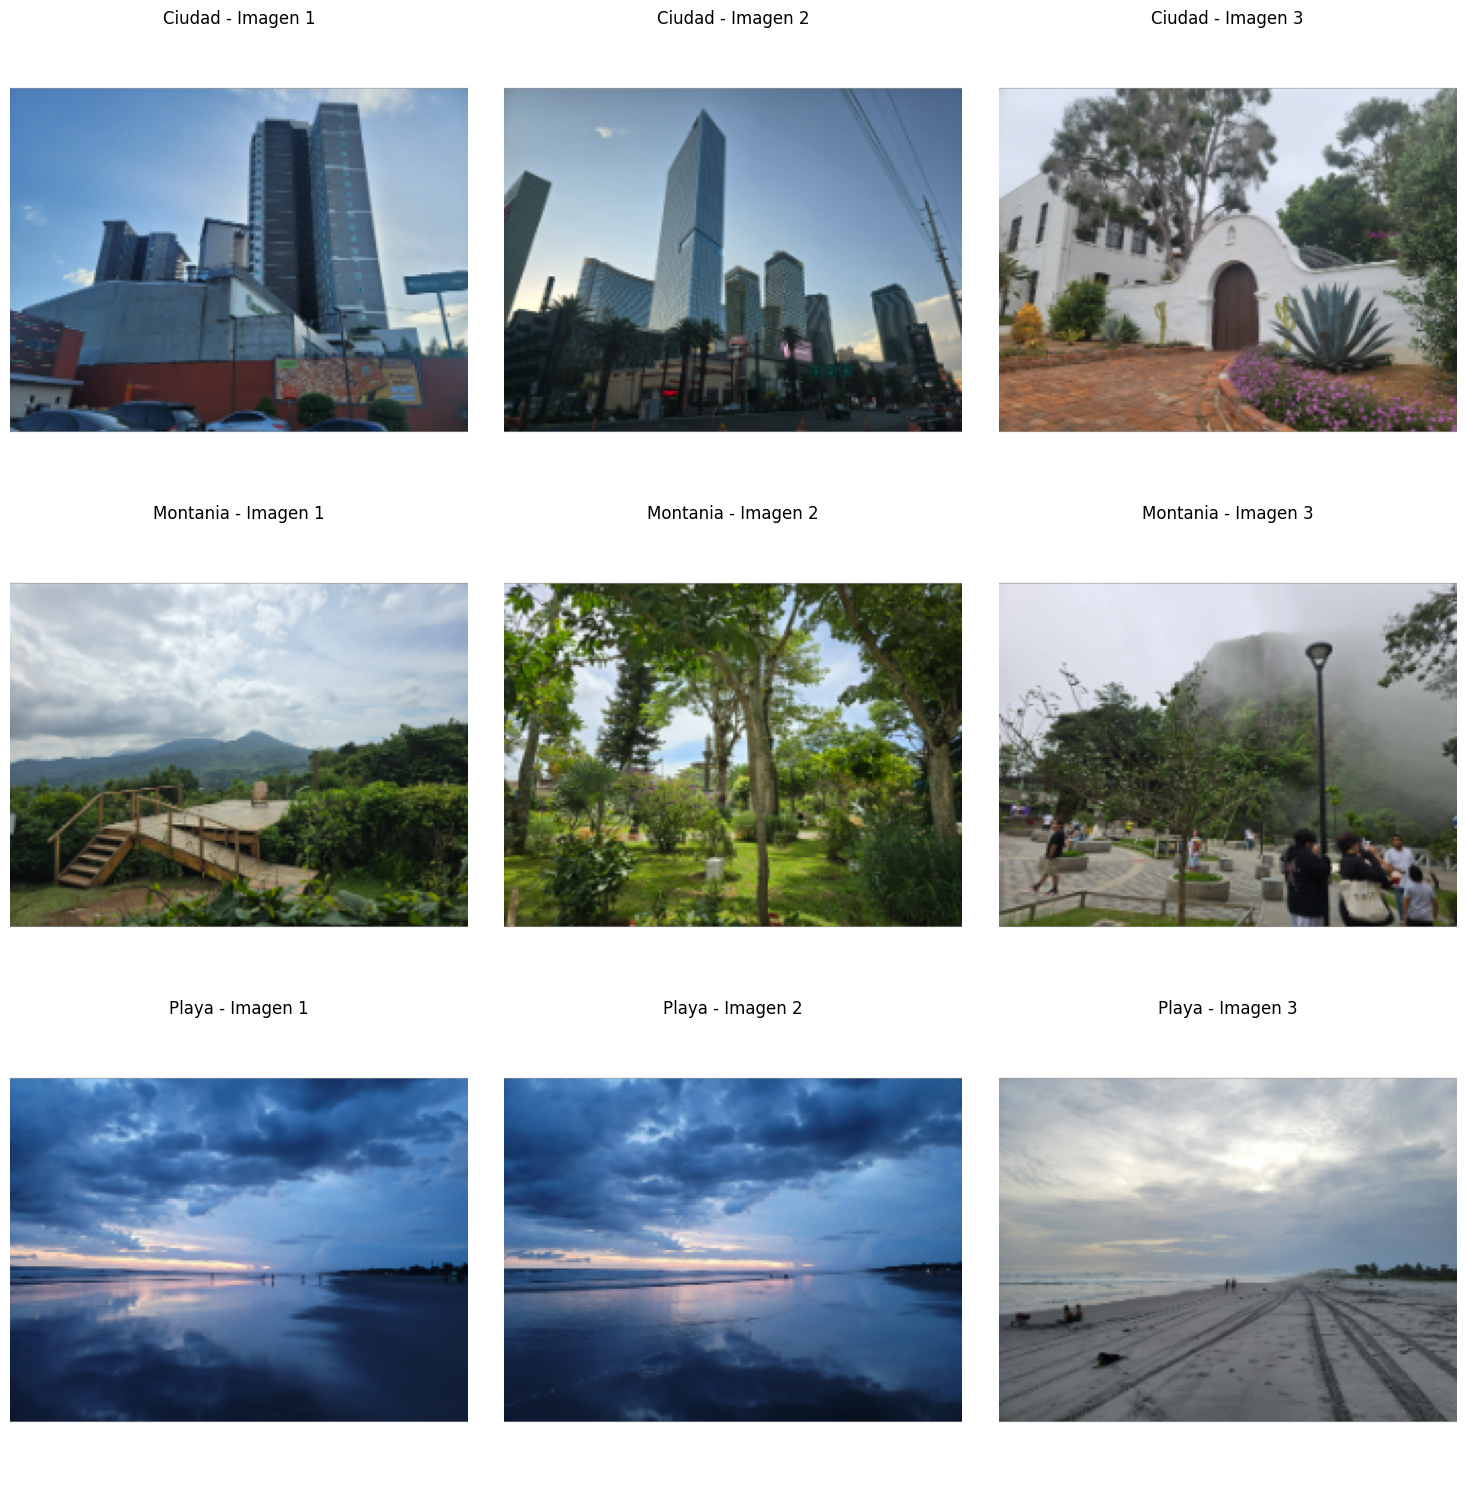

In [4]:
# TODO: Visualiza 3 imagenes de cada clase en un grid
# Pista: plt.subplots(filas=NUM_CLASES, columnas=3)

# Tu codigo aqui
fig, axes = plt.subplots(nrows=len(LUGARES), ncols=3, figsize=(15, 5*len(LUGARES)))

for i, lugar in enumerate(LUGARES):
    archivos = [f for f in lugar.iterdir() if f.suffix.lower() in image_extensions]
    for j in range(3):
        if j < len(archivos):
            img = plt.imread(archivos[j])
            axes[i, j].imshow(img)
            axes[i, j].set_title(f'{lugar.name} - Imagen {j+1}')
            axes[i, j].axis('off')

plt.tight_layout()
plt.show()  


## Paso 4: Preparar Datos (30 min)

### TODO 5: Copia tus imagenes a /content/

Operaciones en Drive son lentas. Copia a la carpeta de trabajo.


In [5]:
# TODO: Copia tu dataset a WORK_DIR
# Pista: shutil.copytree(RAW_DATA_DIR, WORK_DIR)
# (asegurate de que WORK_DIR no exista antes)

# Tu codigo aqui
shutil.copytree(RAW_DATA_DIR, WORK_DIR)
print(f'Dataset copiado a: {WORK_DIR}')




Dataset copiado a: /content/drive/MyDrive/turismo/work


### TODO 6: Crea generadores de datos

Necesitas dos generadores:
- **train_datagen** con `preprocess_input` y augmentation
- **val_datagen** con `preprocess_input` SIN augmentation

> **Importante**: Como vamos a usar Transfer Learning con ResNet50, debes usar `preprocess_input` de ResNet50, NO `rescale=1./255`. Es lo que vimos en clase.

**Configuracion sugerida**:
- IMG_SIZE = 160 (suficiente para ResNet50)
- BATCH_SIZE = 32
- validation_split = 0.2


In [7]:
# TODO: Importa lo necesario
# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# from tensorflow.keras.applications.resnet50 import preprocess_input

# Tu codigo aqui


# Configuracion
IMG_SIZE_TL = 224        # Para Transfer Learning (ResNet50 funciona bien aqui)
BATCH_SIZE = 32
NUM_CLASSES = len(LUGARES)
VALIDATION_SPLIT = 0.2

print(f'Tamano de imagen para ResNet50:    {IMG_SIZE_TL}x{IMG_SIZE_TL}')
print(f'Batch size: {BATCH_SIZE}')
print(f'Numero de clases: {NUM_CLASSES}')
print(f'Validacion: {VALIDATION_SPLIT:.0%}')

# TODO: Crea train_datagen con augmentation y preprocess_input
# TODO: Crea val_datagen solo con preprocess_input

train_datagen = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=preprocess_input,
    rotation_range=40,
    width_shift_range=0.1,
    height_shift_range=0.1,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=VALIDATION_SPLIT
)

val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, 
    validation_split=VALIDATION_SPLIT
)


# TODO: Conecta con flow_from_directory
# train_generator = train_datagen.flow_from_directory(...)
# val_generator = val_datagen.flow_from_directory(...)
#
# Importante: shuffle=False en val_generator (para que coincida con classes)

# Tu codigo aqui
train_generator = train_datagen.flow_from_directory(
    WORK_DIR,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=SEED   
)

val_generator = val_datagen.flow_from_directory(
    WORK_DIR,
    target_size=(IMG_SIZE_TL, IMG_SIZE_TL),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=SEED
)   


# Validar
class_indices = train_generator.class_indices
print(f'Clases: {class_indices}')


Tamano de imagen para ResNet50:    224x224
Batch size: 32
Numero de clases: 3
Validacion: 20%
Found 192 images belonging to 3 classes.
Found 48 images belonging to 3 classes.
Clases: {'Ciudad': 0, 'Montania': 1, 'Playa': 2}


## Paso 5: Entrenar con Transfer Learning (1-2 horas)

Aqui es donde brilla el Transfer Learning. Usaras ResNet50 pre-entrenada en ImageNet y solo entrenaras una cabeza nueva para tu problema.

### Por que NO entrenamos una CNN desde cero

En clase ya entrenamos una CNN simple desde cero (Simpsons). Aqui usamos directamente lo que mejor funciona en la practica: **Transfer Learning**.

### TODO 7: Carga ResNet50 pre-entrenada

**Argumentos**:
- `weights='imagenet'`
- `include_top=False`
- `input_shape=(IMG_SIZE, IMG_SIZE, 3)`

Despues: **CONGELAR** con `base_model.trainable = False`


In [8]:
# TODO: Carga ResNet50 pre-entrenada y congelala
# from tensorflow.keras.applications import ResNet50

# Tu codigo aqui
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
base_model.trainable = False
print('ResNet50 cargada y congelada.')





94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 6s 0us/step
ResNet50 cargada y congelada.


### TODO 8: Construye el modelo completo

**Importante**: Usa Functional API con `training=False` (lo que vimos en clase para arreglar el bug de BatchNormalization).

Estructura:
```text
inputs = Input((IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dense(256, 'relu')(x)
x = BatchNormalization()(x)
x = Dropout(0.5)(x)
outputs = Dense(NUM_CLASSES, 'softmax')(x)
model = keras.Model(inputs, outputs)
```


In [9]:
# TODO: Construye el modelo con Functional API + training=False

def crear_modelo():
    inputs = keras.Input(shape=(IMG_SIZE_TL, IMG_SIZE_TL, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    outputs = layers.Dense(len(class_indices), activation='relu')(x)
    modelo = keras.Model(inputs, outputs)
    return modelo    

modelo = crear_modelo()
modelo.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ resnet50 (Functional)           │ (None, 7, 7, 2048)     │    23,587,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         6,147 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,593,859 (90.00 MB)

 Trainable params: 6,147 (24.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

### TODO 9: Compila y entrena

- Optimizer: Adam con learning_rate=0.001
- Loss: categorical_crossentropy
- 8-10 epocas suelen ser suficientes
- Usa EarlyStopping (patience=3)


In [10]:
resultados = []

# funciones bastante utiles para visualizar resultados y registrar metricas
def plot_history(history, title='Modelo'):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(history.history['accuracy'], label='Entrenamiento', linewidth=2)
    axes[0].plot(history.history['val_accuracy'], label='Validacion', linewidth=2)
    axes[0].set_title(f'{title} - Accuracy')
    axes[0].set_xlabel('Epoca')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()

    axes[1].plot(history.history['loss'], label='Entrenamiento', linewidth=2)
    axes[1].plot(history.history['val_loss'], label='Validacion', linewidth=2)
    axes[1].set_title(f'{title} - Loss')
    axes[1].set_xlabel('Epoca')
    axes[1].set_ylabel('Loss')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

def registrar_resultado(nombre, loss, accuracy):
    global resultados
    resultados = [r for r in resultados if r['Modelo'] != nombre]
    resultados.append({
        'Modelo': nombre,
        'Loss': loss,
        'Accuracy': accuracy,
        'Accuracy %': accuracy * 100
    })
    print(f'{nombre}: accuracy={accuracy:.4f} ({accuracy*100:.1f}%), loss={loss:.4f}')

# TODO: Compila el modelo
opt = tf.keras.optimizers.Adam(learning_rate=0.001)
modelo.compile(
    optimizer=opt,
    loss='categorical_crossentropy',
    metrics=['accuracy']    
)


# TODO: Define callbacks (EarlyStopping)
callbacks = [
    EarlyStopping(monitor='val_loss', patience=7, restore_best_weights=True)
]


EPOCHS = 20  # ajusta si necesitas

# TODO: Entrena el modelo
# history = modelo.fit(...)
history = modelo.fit(
    train_generator,
    validation_data=val_generator,
    epochs=EPOCHS,
    callbacks=callbacks
)

# Tu codigo aqui
registrar_resultado('ResNet50 Congelada', history.history['val_loss'][-1], history.history['val_accuracy'][-1])


Epoch 1/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 52s 8s/step - accuracy: 0.2865 - loss: 5.8802 - val_accuracy: 0.3750 - val_loss: 5.1219
Epoch 2/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.3073 - loss: 5.8421 - val_accuracy: 0.3542 - val_loss: 6.8680
Epoch 3/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.3177 - loss: 5.8371 - val_accuracy: 0.3333 - val_loss: 7.1869
Epoch 4/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.4635 - loss: 5.8256 - val_accuracy: 0.3333 - val_loss: 7.5333
Epoch 5/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 43s 7s/step - accuracy: 0.4167 - loss: 5.8228 - val_accuracy: 0.3333 - val_loss: 8.1131
Epoch 6/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.4375 - loss: 5.8232 - val_accuracy: 0.3333 - val_loss: 8.1384
Epoch 7/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.5104 - loss: 5.8119 - val_accuracy: 0.3333 - val_loss: 8.1567
Epoch 8/20
6/6 ━━━━━━━━━━━━━━━━━━━━ 41s 7s/step - accuracy: 0.4792 - loss: 5.8125 - val_accuracy: 0.3333 - val_loss: 8.1668
ResNet50

### TODO 10: Visualiza curvas de entrenamiento

Grafica accuracy y loss para train y val.


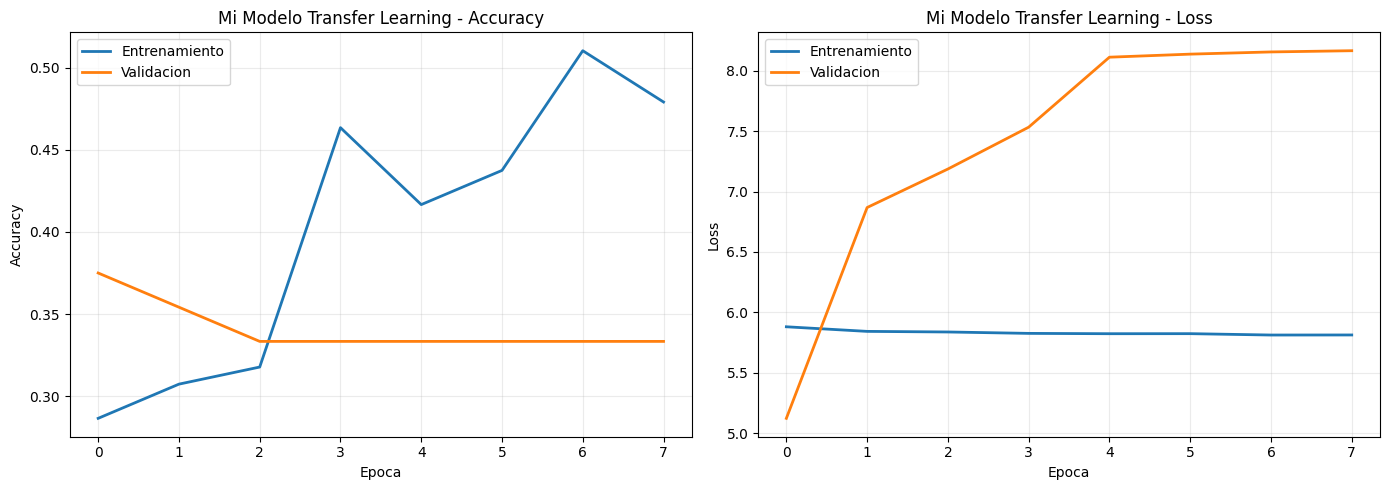

In [11]:
# TODO: Funcion para graficar accuracy y loss
plot_history(history, 'Mi Modelo Transfer Learning')


### Reflexion

- Tu modelo mostro overfitting?
- Que accuracy obtuviste en validation?
- Si esta por debajo del 70%, considera:
  - Mas imagenes por clase
  - Augmentation mas agresiva
  - Mas epocas
  - Verificar que tus clases son distinguibles

---


## Paso 6: Analizar Errores (45 min)

Mas alla del accuracy global, necesitas saber QUE confunde tu modelo.

### TODO 11: Genera predicciones


In [12]:
# TODO: Genera predicciones en val_generator
# Pasos:
# 1. val_generator.reset()
# 2. predicciones = modelo.predict(val_generator)
# 3. y_pred = np.argmax(predicciones, axis=1)
# 4. y_true = val_generator.classes

# Tu codigo aqui
val_generator.reset()
predicciones = modelo.predict(val_generator)
y_pred = np.argmax(predicciones, axis=1)
y_true = val_generator.classes





2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 7s/step


### TODO 12: Confusion Matrix

Visualiza con `seaborn.heatmap` para ver que clases se confunden entre si.


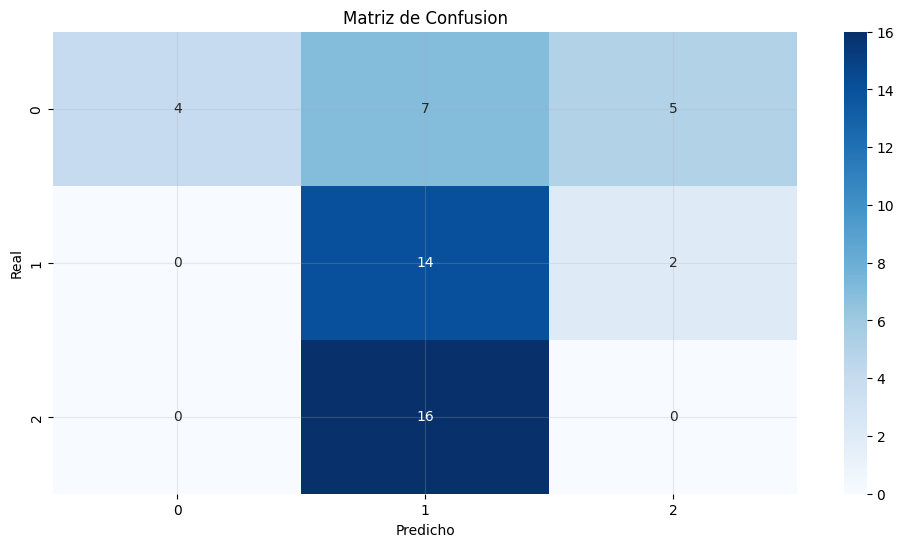

In [13]:
# TODO: Confusion Matrix
# from sklearn.metrics import confusion_matrix
# import seaborn as sns

# Tu codigo aqui

sns.heatmap(confusion_matrix(y_true, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title('Matriz de Confusion')
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.show()  



### TODO 13: Classification Report

Te da precision, recall y F1 por cada clase.


In [14]:
# TODO: Classification Report
# from sklearn.metrics import classification_report

# Tu codigo aqui
print('Classification Report:')
print(classification_report(y_true, y_pred, target_names=list(class_indices.keys())))   






Classification Report:
              precision    recall  f1-score   support

      Ciudad       1.00      0.25      0.40        16
    Montania       0.38      0.88      0.53        16
       Playa       0.00      0.00      0.00        16

    accuracy                           0.38        48
   macro avg       0.46      0.38      0.31        48
weighted avg       0.46      0.38      0.31        48



### TODO 14: Visualiza errores especificos

Muestra 6 imagenes que el modelo predijo MAL, con su prediccion incorrecta y la real. **Esto es oro para el README**: te dara material para reflexionar sobre por que falla.


Numero de errores: 30


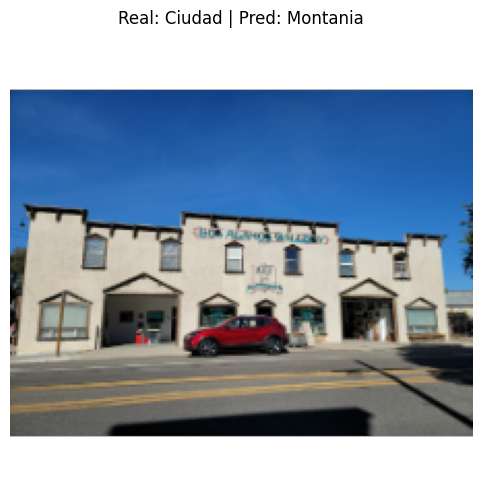

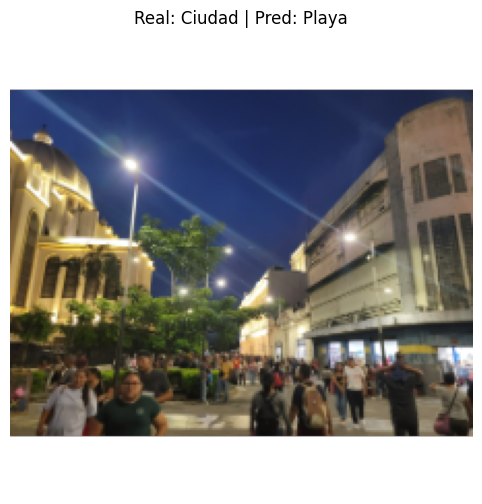

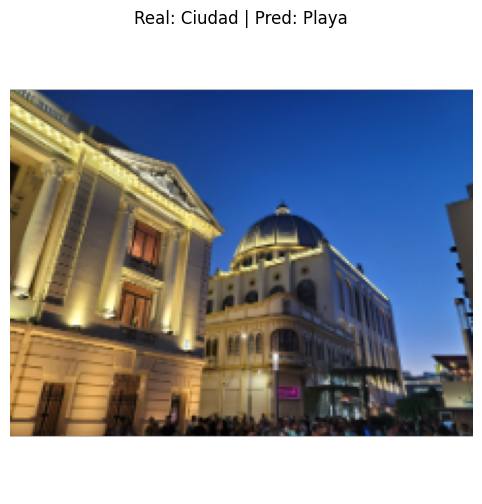

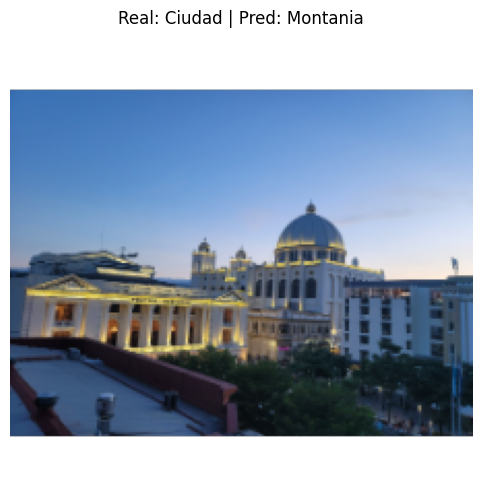

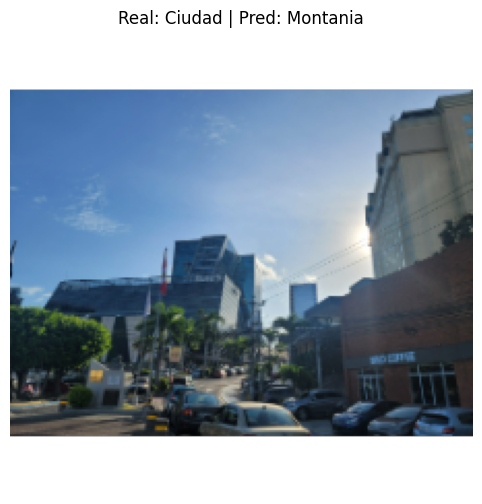

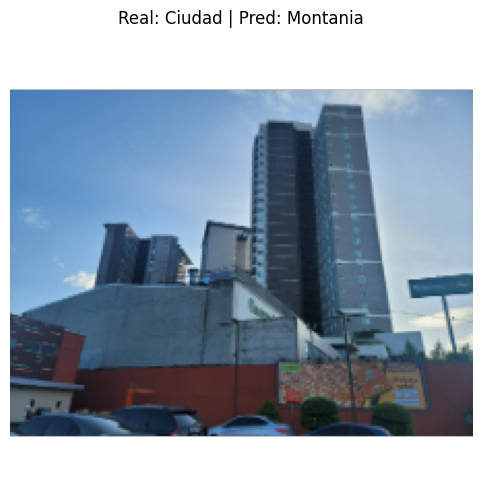

In [15]:
# TODO: Muestra 6 errores del modelo
# Pasos:
# 1. Encuentra indices donde y_pred != y_true
# 2. Muestra esas imagenes con titulo "Real: X | Pred: Y"

# Tu codigo aqui
errores = np.where(y_pred != y_true)[0]
print(f'Numero de errores: {len(errores)}')

for i in range(min(6, len(errores))):
    idx = errores[i]
    img_path = val_generator.filepaths[idx]
    img = plt.imread(img_path)
    real_label = list(class_indices.keys())[y_true[idx]]
    pred_label = list(class_indices.keys())[y_pred[idx]]
    
    plt.imshow(img)
    plt.title(f'Real: {real_label} | Pred: {pred_label}')
    plt.axis('off')
    plt.show()




### Reflexion (importante para tu README)

Mira las imagenes mal clasificadas:
- Hay un patron en los errores?
- Que clase confunde mas?
- Por que crees que pasa?

Anota tus reflexiones, las usaras en el README.

---


## Paso 7: Guardar Modelo y Crear App Streamlit (2-3 horas)

### TODO 15: Guarda el modelo

Tambien guarda el mapeo de clases para usarlo en la app.


In [16]:
# TODO: Guardar modelo y class_indices
#
# modelo.save('mi_modelo.keras')
#
# import json
# with open('clases.json', 'w') as f:
#     json.dump(class_indices, f)

modelo.save(Path(ROOT) / 'mi_modelo.keras')
with open(Path(ROOT) /'clases.json', 'w') as f:
    json.dump(class_indices, f)

from google.colab import files
files.download(Path(ROOT) / 'mi_modelo.keras')
files.download(Path(ROOT) / 'clases.json')

# Para descargar a tu computadora:
# from google.colab import files
# files.download('mi_modelo.keras')
# files.download('clases.json')


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

### Sobre Streamlit

**Streamlit** convierte scripts Python en aplicaciones web. No necesitas saber HTML, CSS ni JavaScript.

**Por que Streamlit en lugar de Gradio**:
- Deploy en Streamlit Cloud es muy simple
- Conexion automatica con GitHub (haces push, se actualiza solo)
- Comunidad activa, mucha documentacion

### TODO 16: Disena tu app.py

Crea un archivo `app.py` que:
1. Cargue tu modelo
2. Permita al usuario subir una imagen
3. Muestre la prediccion con barras de probabilidad

**Estructura tipica de una Streamlit app**:

```python
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import json
from tensorflow.keras.applications.resnet50 import preprocess_input

# Cache para no cargar el modelo en cada interaccion
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('mi_modelo.keras')
    with open('clases.json') as f:
        class_indices = json.load(f)
    idx_to_class = {v: k for k, v in class_indices.items()}
    return model, idx_to_class

modelo, idx_to_class = load_model()

st.title('Mi Clasificador')
st.write('Sube una imagen para clasificar')

uploaded_file = st.file_uploader('Imagen', type=['jpg', 'jpeg', 'png'])

if uploaded_file is not None:
    # Mostrar imagen
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Imagen subida', use_column_width=True)
    
    # Preprocesar
    IMG_SIZE = 160  # el mismo que usaste en entrenamiento
    img_resized = image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_resized)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predecir
    pred = modelo.predict(img_array, verbose=0)[0]
    
    # Mostrar resultados
    st.subheader('Predicciones:')
    for idx in pred.argsort()[::-1]:
        nombre = idx_to_class[idx].replace('_', ' ').title()
        prob = pred[idx]
        st.write(f'**{nombre}**: {prob:.1%}')
        st.progress(float(prob))
```

### TODO 16: Adapta este codigo a tu proyecto

Escribe tu version de `app.py` en la siguiente celda (esta no se ejecuta, es para que tengas el codigo listo).


In [ ]:
# TODO: Tu app.py adaptado
# Esta celda NO se ejecuta - solo tienes el codigo listo para copiar

codigo_app_py = '''

import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import json
from tensorflow.keras.applications.resnet50 import preprocess_input

# Cache para no cargar el modelo en cada interaccion
@st.cache_resource
def load_model():
    model = tf.keras.models.load_model('mi_modelo.keras')
    with open('clases.json') as f:
        class_indices = json.load(f)
    idx_to_class = {v: k for k, v in class_indices.items()}
    return model, idx_to_class

modelo, idx_to_class = load_model()

st.title('Clasificador de Lugares Turisticos')
st.write('Sube una imagen para clasificar')

uploaded_file = st.file_uploader('Imagen', type=['jpg', 'jpeg', 'png'])

if uploaded_file is not None:
    # Mostrar imagen
    image = Image.open(uploaded_file).convert('RGB')
    st.image(image, caption='Imagen subida', width=500)
    
    # Preprocesar
    IMG_SIZE = 224  # el mismo que usaste en entrenamiento
    img_resized = image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img_resized)
    img_array = preprocess_input(img_array)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Predecir
    pred = modelo.predict(img_array, verbose=0)[0]
    
    # Mostrar resultados
    st.subheader('Predicciones:')
    for idx in pred.argsort()[::-1]:
        nombre = idx_to_class[idx].replace('_', ' ').title()
        prob = pred[idx]
        st.write(f'**{nombre}**: {prob:.1%}')
        if(prob>1):
            prob = 1
        try:            
            st.progress(float(prob))    
        except:
            pass

'''

print(codigo_app_py)


## Paso 8: Deploy en Streamlit Cloud (1-2 horas)

### Por que Streamlit Cloud

- Gratis
- Conecta con GitHub: haces push y la app se re-deploya sola
- URL publica permanente
- Setup en ~3 minutos una vez tienes los archivos

### Pasos paso a paso

#### Paso A: Crear repositorio en GitHub

1. Crea una cuenta en GitHub si no tienes
2. Crea un repo publico nuevo, ej: `mi-clasificador`
3. **NO** lo inicialices con README

#### Paso B: Subir tus archivos al repo

Tu repositorio debe tener estos 4 archivos en la raiz:

```text
mi-clasificador/
  app.py              <- el codigo de Streamlit
  mi_modelo.keras     <- tu modelo guardado
  clases.json         <- mapeo de clases
  requirements.txt    <- dependencias
```

**Contenido de `requirements.txt`**:

```text
streamlit
tensorflow
numpy
pillow
```

> **Importante**: Si tu modelo `.keras` pesa mas de 100MB, GitHub te bloqueara el push. Si pasa, usa Git LFS o reduce tu modelo cambiando IMG_SIZE a 128.

Sube los archivos:
- Opcion facil: usa la interfaz web de GitHub (Add file > Upload files)
- Opcion git: clona el repo, copia los archivos, `git add .`, `git commit`, `git push`

#### Paso C: Conectar Streamlit Cloud

1. Ir a https://streamlit.io/cloud
2. Sign in with GitHub
3. Click en **New app**
4. Selecciona tu repositorio (`mi-clasificador`)
5. Branch: `main`, Main file path: `app.py`
6. Click en **Deploy**

#### Paso D: Esperar el build

Streamlit instala dependencias y arranca tu app (3-5 min). Cuando termine veras tu URL:

`https://mi-clasificador-xxxxxxx.streamlit.app`

Esa es tu app publica permanente.

### Si algo falla

**Error: dependencias no encontradas**
- Verifica `requirements.txt` (debe tener todas las librerias)

**Error: archivo no encontrado al cargar modelo**
- Verifica que `mi_modelo.keras` y `clases.json` estan en el repo
- Usa rutas relativas en `app.py`, no absolutas

**Error: out of memory**
- Tu modelo es muy grande
- Reduce IMG_SIZE y re-entrena, o usa MobileNetV2 que es mas pequeno

**App carga pero predice mal**
- Verifica que IMG_SIZE en `app.py` coincide con el del entrenamiento
- Verifica que usas `preprocess_input` igual que en entrenamiento

### TODO 17: Verifica tu deploy

Pega aqui la URL de tu app cuando este funcionando.


In [ ]:
# TODO: Verifica que tu app funciona

URL_APP = ''  # Pega la URL de tu Streamlit app aqui

assert URL_APP.startswith('https://'), 'Pega una URL valida'
assert 'streamlit.app' in URL_APP, 'Debe ser una URL de Streamlit Cloud'

print(f'Mi app: {URL_APP}')
print('\nChecklist final:')
print('[ ] La app carga sin errores')
print('[ ] Puedo subir una imagen')
print('[ ] El modelo predice correctamente')
print('[ ] Las probabilidades se muestran bien')


## Paso 9: Documentar (1 hora)

### Por que importa el README

El README es la primera impresion. Reclutadores y profesores leen el README antes que el codigo.

### Estructura recomendada

Crea un archivo `README.md` en tu repo de GitHub con esta estructura:

```markdown
# Mi Proyecto: [Nombre]

## Descripcion
2-3 oraciones sobre que hace tu clasificador.

## Demo
[URL de tu app en Streamlit Cloud]

## Por que este tema
Por que lo elegiste y por que importa.

## Dataset
- Total de imagenes: X
- Clases: lista
- Fuentes: de donde vinieron las imagenes

## Resultados
Mejor accuracy obtenido: XX%

| Clase | Precision | Recall | F1 |
|-------|-----------|--------|-----|
| ...   | ...       | ...    | ... |

## Analisis de errores
Que confunde tu modelo y por que crees que sucede.
Incluye 1-2 imagenes de ejemplos mal clasificados.

## Aprendizajes
Que fue lo mas dificil. Que aprendiste.

## Tecnologias usadas
- Python, TensorFlow/Keras
- Transfer Learning con ResNet50
- Streamlit para interfaz
- Streamlit Cloud para deploy

## Autor
Tu nombre
```

### TODO 18: Crea tu README

Escribe el README, subelo al repo de GitHub junto con `app.py`. Listo, ya tienes proyecto completo.

---

## Checklist Final de Entrega

Antes de entregar, verifica TODO:

### Notebook
- [ ] Todas las celdas se ejecutan sin errores
- [ ] Cada TODO esta completado
- [ ] Hay reflexiones escritas, no solo codigo

### Modelo
- [ ] Lograste minimo 70% de accuracy en validation
- [ ] Tienes confusion matrix
- [ ] Analizaste errores especificos

### App
- [ ] La URL de Streamlit funciona
- [ ] Cualquier persona puede acceder y usar tu app
- [ ] La app carga el modelo y predice correctamente

### GitHub
- [ ] Repo publico con `app.py`, modelo, clases.json, requirements.txt
- [ ] README.md completo con demo URL

---

## Como Entregar

1. **Notebook completado** (.ipynb): subir al sistema del curso
2. **URL de Streamlit**: pegar en formulario
3. **URL del repo de GitHub**: pegar en formulario

**Fecha limite**: el profesor te dira

---

## Plan de Trabajo Sugerido

Si tienes ~2 horas por noche, este es un plan realista:

| Dia | Que hacer | Tiempo |
|-----|-----------|--------|
| Lunes | Planificar, empezar a recolectar imagenes | 2h |
| Martes | Terminar recoleccion, organizar en Drive | 2h |
| Miercoles | Explorar dataset, preparar generadores | 1.5h |
| Jueves | Entrenar Transfer Learning, ajustar | 2h |
| Viernes | Analizar errores, guardar modelo, escribir app.py | 2h |
| Sabado | Deploy en Streamlit Cloud, debug | 2h |
| Domingo | README, pulir todo, entregar | 1.5h |

Total: ~13 horas distribuidas. Si vas adelantado en algun dia, descansas el siguiente.

---

## Tips Finales

### Si tu accuracy es bajo (<70%)

1. Mas imagenes (objetivo: 50+ por clase)
2. Augmentation mas agresiva (rotacion, zoom, flip)
3. Mas epocas (15-20 con EarlyStopping)
4. Verifica que tus clases son visualmente distinguibles

### Si tu app tiene problemas

1. Lee los logs de Streamlit Cloud (boton "Manage app")
2. Verifica versiones en `requirements.txt`
3. Prueba localmente primero: `streamlit run app.py`

### Para que tu proyecto destaque

- **Tema unico**: no copies ideas obvias
- **README cuidado**: con capturas, ejemplos, reflexiones
- **App profesional**: titulo claro, descripcion, ejemplo de uso

---

## Conclusion del Modulo

Has completado **TODO el Modulo 4**:

- Sesion 1: Modelos clasicos
- Sesion 2: ML en produccion (XGBoost + FastAPI)
- Sesion 3: Procesamiento de imagenes
- Sesion 4: CNNs + este proyecto final

Ahora tienes habilidades reales para resolver problemas de Machine Learning de principio a fin.

Exito con tu proyecto!

